# **Assignment 14_Ethical AI Analysis**

## **Fairness and Explainability in Machine Learning for Heart Disease Prediction**

*The objective of this project is to develop a Logistic Regression model to predict heart disease and evaluate its performance, fairness, and explainability. We will use the Heart Disease dataset from UCI repository*

### **1. Data preparation**

In [33]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
%pip install ucimlrepo fairlearn shap lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   - -------------------------------------- 1.6/43.0 MB 8.7 MB/s eta 0:00:05
   -- ------------------------------------- 3.1/43.0 MB 7.7 MB/s eta 0:00:06
   ---- ----------------------------------- 5.0/43.0 MB 8.4 MB/s eta 0:00:05
   ----- ---------------------------------- 5.8/43.0 MB 7.4 MB/s eta 0:00:06
   ------ --------------------------------- 6.6/43.0 MB 6.6 MB/s eta 0:00:06
   ------- -------------------------------- 8.4/43.0 MB 6.7 MB/s eta 0:00:06
   --------- ------------------------------ 9.7/43.0 MB 6.5 MB/s eta 0:00:06
   ---------- ----------------------------- 11.8/43.0 MB 7.1 


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Load the heart disease dataset

from ucimlrepo import fetch_ucirepo

# Load Heart Disease dataset
heart = fetch_ucirepo(id=45)

# Features and target
X = heart.data.features.copy()
y = heart.data.targets.copy()

In [ ]:
# Show the first 5 rows for the features

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [6]:
# Show the first 5 rows for the target variable

y.head()

,num
0,0
1,2
2,1
3,0
4,0


In [ ]:
# Examine the dataset

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [ ]:
# Outcome variable

y.value_counts()

num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64

##### *The outcome variable:*

0: No heart disease;
1: Heart disease — level 1;
2: Heart disease — level 2;
3: Heart disease — level 3;
4: Heart disease — level 4

In [ ]:
# Convert target to binary

y = (y['num'] > 0).astype(int)

In [ ]:
# Sow the binary outcome variable
y.value_counts()

num
0    164
1    139
Name: count, dtype: int64

In [13]:
# Identify the sensitive attribute

sensitive_feature = X['sex'].copy()

sensitive_feature.value_counts()

sex
1    206
0     97
Name: count, dtype: int64

In [14]:
X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [15]:
# Fill in the missing values

X['ca'] = X['ca'].fillna(X['ca'].mode()[0])
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

In [16]:
X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

## **2. Model Training and Evaluation**

In [20]:
# Remove sex from model predictors

X_model = X.drop(columns=['sex'])


In [21]:
X_model.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
# Split the data

X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X_model,
    y,
    sensitive_feature,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [27]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Train the Logistic Regression Model

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [30]:
# Make prediction

y_pred = log_model.predict(X_test_scaled)

In [32]:
# Evaluate the model

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Heart Disease', 'Heart Disease']))

Accuracy: 0.8360655737704918

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.79      0.84        33
   Heart Disease       0.78      0.89      0.83        28

        accuracy                           0.84        61
       macro avg       0.84      0.84      0.84        61
    weighted avg       0.84      0.84      0.84        61



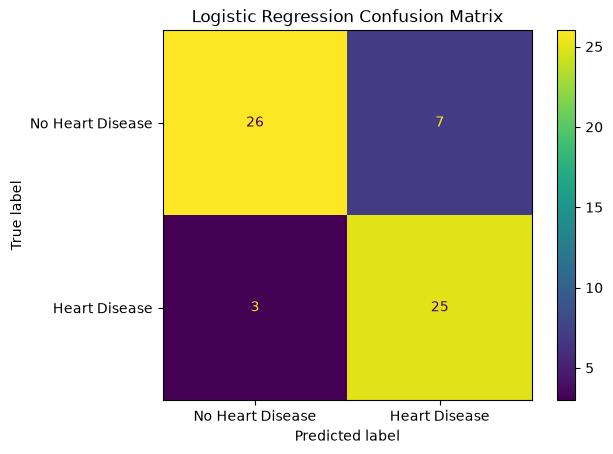

In [34]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Heart Disease', 'Heart Disease'])

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## **3. Fairness Analysis**

In [35]:
%pip install fairlearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import libraries

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate)

In [39]:
# Define fairness metrics

metrics = {
    'Selection Rate': selection_rate,
    'False Positive Rate': false_positive_rate,
    'True Positive Rate': true_positive_rate}

In [ ]:
# Calculate fairness by sex

fairness = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test)

fairness.by_group

,Selection Rate,False Positive Rate,True Positive Rate
sex,,,
0,0.350000,0.076923,0.857143
1,0.609756,0.300000,0.904762


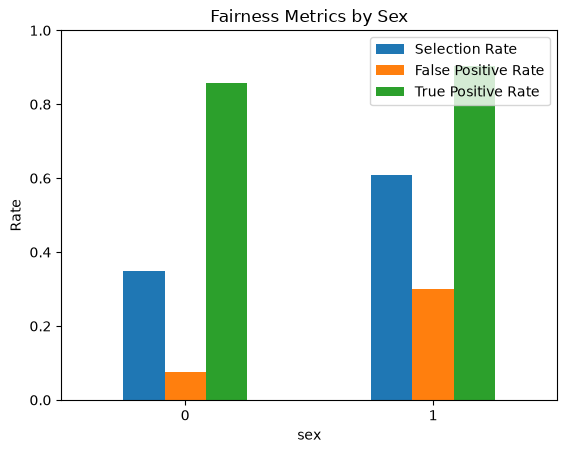

In [ ]:
# Visualize the metrics by sex

fairness.by_group.plot(kind='bar')

plt.title('Fairness Metrics by Sex')
plt.ylabel('Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### **Conclusion:**

Fairness Analysis: Fairlearn was used to evaluate selection rate, false positive rate, and true positive rate across sex groups. The true positive rates were relatively similar between group 0 (approximately 86%) and group 1 (approximately 82%). However, differences were observed in the selection and false positive rates. The selection rate was approximately 35% for group 0 compared with 61% for group 1, while the false positive rate was approximately 8% and 30%, respectively. These findings indicate differences in model behaviour across the two groups, particularly in false-positive predictions. However, because the dataset and test-set subgroups are small, these differences should be interpreted cautiously and do not by themselves establish that the model is discriminatory.